In [126]:
from langgraph.graph import MessagesState
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import RemoveMessage, HumanMessage
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver
from langchain_groq import ChatGroq

In [127]:
load_dotenv()

True

In [128]:
LLM = ChatGroq(model="openai/gpt-oss-120b", temperature=0.5)

In [129]:
class summarystate(MessagesState):
    summary: str

In [130]:
def chat_node(state: summarystate):

    print("NUMBER OF MESSAGES:", len(state["messages"]))

    for i, msg in enumerate(state["messages"]):
        print(i, type(msg).__name__, msg.content[:100])

    messages = []

    if state["summary"]:
        messages.append({
            "role": "system",
            "content": f"Conversation Summary: {state['summary']}"
        })

    messages.extend(state["messages"])

    print("MESSAGES SENT TO LLM:", len(messages))

    response = LLM.invoke(messages)

    return {"messages": [response]}

In [131]:
def summarry_node(state: summarystate):

    existing_summary = state["summary"]

    if existing_summary:
        prompt = (
            f"Existing summary:\n{existing_summary}\n\n"
            "Extend the summary using the new conversation."
        )
    else:
        prompt = "Summarize the conversation."

    message_for_summary = (
        state["messages"] +
        [HumanMessage(content=prompt)]
    )

    response = LLM.invoke(message_for_summary)

    # Keep only the last 2 messages
    messages_to_delete = state["messages"][:-2]

    return {
        "summary": response.content,
        "messages": [
            RemoveMessage(id=m.id)
            for m in messages_to_delete
        ]
    }

In [132]:
def should_summarize(state: summarystate):

    print("SHOULD SUMMARIZE CHECK:", len(state["messages"]))

    return len(state["messages"]) >= 6

In [133]:
#building the node
graph = StateGraph(summarystate)

graph.add_node("chat_node", chat_node)
graph.add_node("summarry_node", summarry_node)

graph.add_conditional_edges(
    START,
    should_summarize,
    {
        True: "summarry_node",
        False: "chat_node"
    }
)

graph.add_edge("summarry_node", "chat_node")
graph.add_edge("chat_node", END)


In [134]:
#implementing checkpointer
memory = InMemorySaver()
STM_summarize = graph.compile(checkpointer=memory)


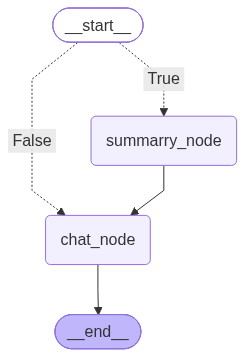

In [135]:
from IPython.display import Image
Image(STM_summarize.get_graph().draw_mermaid_png())

In [136]:
config = {"configurable": {"thread_id": "t1"}}
def run_state(text: str):
    output = STM_summarize.invoke({"messages": [HumanMessage(content=text)], "summary": ""}, config=config)
    return output

In [137]:
# gives the current version of the state
def show_state():
    snap = STM_summarize.get_state(config)
    vals = snap.values

    print("\n--- STATE ---")
    print("summary:", vals.get("summary", ""))
    print("num_messages:", len(vals.get("messages", [])))
    print("messages:")

    for m in vals.get("messages", []):
        print(" -", type(m).__name__, ":", m.content[:80])

In [138]:
run_state("ancient egypt")
show_state()

SHOULD SUMMARIZE CHECK: 1
NUMBER OF MESSAGES: 1
0 HumanMessage ancient egypt
MESSAGES SENT TO LLM: 1

--- STATE ---
summary: 
num_messages: 2
messages:
 - HumanMessage : ancient egypt
 - AIMessage : ## Ancient Egypt – A Quick Overview

### 1. Geography & Why It Mattered
| Featur


In [139]:
run_state("can you tell me important events in ancient egypt")
show_state()

SHOULD SUMMARIZE CHECK: 3
NUMBER OF MESSAGES: 3
0 HumanMessage ancient egypt
1 AIMessage ## Ancient Egypt – A Quick Overview

### 1. Geography & Why It Mattered
| Feature | Importance |
|--
2 HumanMessage can you tell me important events in ancient egypt
MESSAGES SENT TO LLM: 3

--- STATE ---
summary: 
num_messages: 4
messages:
 - HumanMessage : ancient egypt
 - AIMessage : ## Ancient Egypt – A Quick Overview

### 1. Geography & Why It Mattered
| Featur
 - HumanMessage : can you tell me important events in ancient egypt
 - AIMessage : ## Key Milestones in Ancient Egyptian History  

Below is a chronological “road‑


In [140]:
run_state("during these civilization which ever monuments, tombs, god made name them ")
show_state()

SHOULD SUMMARIZE CHECK: 5
NUMBER OF MESSAGES: 5
0 HumanMessage ancient egypt
1 AIMessage ## Ancient Egypt – A Quick Overview

### 1. Geography & Why It Mattered
| Feature | Importance |
|--
2 HumanMessage can you tell me important events in ancient egypt
3 AIMessage ## Key Milestones in Ancient Egyptian History  

Below is a chronological “road‑map” of the most con
4 HumanMessage during these civilization which ever monuments, tombs, god made name them 
MESSAGES SENT TO LLM: 5

--- STATE ---
summary: 
num_messages: 6
messages:
 - HumanMessage : ancient egypt
 - AIMessage : ## Ancient Egypt – A Quick Overview

### 1. Geography & Why It Mattered
| Featur
 - HumanMessage : can you tell me important events in ancient egypt
 - AIMessage : ## Key Milestones in Ancient Egyptian History  

Below is a chronological “road‑
 - HumanMessage : during these civilization which ever monuments, tombs, god made name them 
 - AIMessage : ## Ancient Egypt – Signature Monuments, Tombs, and Deities by Perio

In [146]:
run_state("take out the hostory of cleopetra and tell her reign stroy to me ")
show_state()

SHOULD SUMMARIZE CHECK: 12
NUMBER OF MESSAGES: 2
0 HumanMessage take out the hostory of cleopetra and tell her reign stroy to me 
1 HumanMessage take out the hostory of cleopetra and tell her reign stroy to me 
MESSAGES SENT TO LLM: 3

--- STATE ---
summary: ## Cleopatra VII Philopator – The Story of Her Reign (51 BC – 30 BC)

| Aspect | Key Points |
|--------|------------|
| **Background** | • Born c. 69 BC in Alexandria, the capital of the Ptolemaic Kingdom (a Greek‑Macedonian dynasty that ruled Egypt after Alexander the Great).<br>• Daughter of Ptolemy XII Auletes; educated in the royal court, she learned Egyptian, Greek, and several other languages (including Latin). |
| **Accession (51 BC)** | • Became co‑ruler with her younger brother **Ptolemy XIII** (the “son of the lamb”) after their father’s death.<br>• The Ptolemaic tradition required a male co‑ruler, so she married her brother to legitimize her claim. |
| **Early Crisis (48 BC)** | • Civil war erupted between Cleopatra’s su